Personal Project
Goal: TBD
Data: Sleep health data from kaggle(https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset)



In [1]:
import pandas as pd # handles data frame and data manipulation
import numpy as np # handles numerical operations; math in general
import matplotlib.pyplot as plt # handles data visualization 
import seaborn as sns # handles data visualization; built on top of matplotlib, provides better aesthetics and easier syntax
from scipy import stats # handles statistical analysis; provides functions for statistical tests, distributions, and etc.

# cosmetic settings, making sure nothing are hidden due to color
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid') # white background with gridlines

# load csv into df and outputs the shape of the data. head() shows first 5 lines
df = pd.read_csv('data/sleep_health_dataset.csv')
print(df.shape)
df.head()

(100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


Organize and decide what i should do w the data set

In [2]:
df.info(verbose=True) # provides a summary of the columns and it's type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

identifier: person_id
Demographics: age, gender, occupation, bmi, country
behavior: sleep_duration_hrs, rem_percentage, sleep_latency_mins, wake_episodes_per_night, heart_rate_resting_bpm

Predetermined factors: chronotype, mental_health_condition,weekend_sleep_diff_hrs, season, day_type, sleep_disorder_risk

Effecting factors: caffeine_mg_before_bed, alcohol_units_before_bed, screen_time_before_bed_mins, exercise_day, steps_that_day, nap_duration_mins,stress_score, work_hours_that_day, sleep_aid_used, shift_work, room_temperature_celsius

outcomes: sleep_duration_score, deep_sleep_percentage, cognitive_performance_score, felt_rested

In [3]:
"""Stores variable lists as python lists, writing them in caps helps consistency
all future cell will refer back to these lists
"""

EFFECTING_FACTORS = ['caffeine_mg_before_bed', 'alcohol_units_before_bed',
                     'screen_time_before_bed_mins', 'exercise_day',
                     'steps_that_day', 'nap_duration_mins', 'stress_score',
                     'work_hours_that_day', 'sleep_aid_used', 'shift_work',
                     'room_temperature_celsius']

OUTCOME_VARIABLES = ['sleep_duration_hrs', 'sleep_quality_score',
                     'felt_rested', 'deep_sleep_percentage']

PREDETERMINED_FACTORS = ['chronotype', 'mental_health_condition',
                         'weekend_sleep_diff_hrs', 'season', 'day_type',
                         'sleep_disorder_risk']

DEMOGRAPHICS = ['age', 'gender', 'occupation', 'bmi', 'country']

# Verify that all expected columns are present
var_verification = EFFECTING_FACTORS + OUTCOME_VARIABLES +\
                   PREDETERMINED_FACTORS + DEMOGRAPHICS # Combines all lists
# Check for each col in df.columns is in var_verification(the big list)
missing_from_df = [col for col in var_verification if col not in df.columns]
print(f'missing columns from dataset: {len(missing_from_df)}, {missing_from_df}')


missing columns from dataset: 0, []


Data consistency: anything about 5% missing value requires alteration
Are there missing values?

In [4]:
missing = df.isnull().sum() # return T/F if missing sum() counts the total
missing_pct = (missing / len(df)) * 100 # percentage of missing

# combnes two series into clean table, and filter to show only missing values
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_percentage': missing_pct
}).query("missing_count > 0").sort_values(by='missing_percentage', ascending=False)

print(missing_report)

Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []


Descriptive stats. Looking for weired min/max values, categories w very few inputs
unexpected nulls

Any impossible/garbage values?

In [5]:
df[EFFECTING_FACTORS+OUTCOME_VARIABLES].describe().T
# Subset to only include EFFECTING_FACTORS and OUTCOME_VARIABLES, 
# then describe() gives summary stats, T transposes the result for better readability

,count,mean,std,min,25%,50%,75%,max
caffeine_mg_before_bed,100000.0,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0
alcohol_units_before_bed,100000.0,0.596800,1.059161,0.0,0.00,0.00,1.00,6.0
screen_time_before_bed_mins,100000.0,63.539620,44.550502,2.0,30.00,51.00,84.00,180.0
exercise_day,100000.0,0.450710,0.497567,0.0,0.00,0.00,1.00,1.0
steps_that_day,100000.0,7496.859740,3460.423881,500.0,5045.00,7442.00,9887.00,20000.0
nap_duration_mins,100000.0,14.936840,21.387567,0.0,0.00,0.00,30.00,116.0
stress_score,100000.0,5.733285,1.619194,1.0,4.80,5.80,6.80,10.0
work_hours_that_day,100000.0,7.134059,3.482878,0.0,4.70,7.40,9.70,18.0
sleep_aid_used,100000.0,0.561610,0.496192,0.0,0.00,1.00,1.00,1.0
shift_work,100000.0,0.084420,0.278018,0.0,0.00,0.00,0.00,1.0


In [6]:
# categorical variables
# loops categorical columns and print count of unique value

for col in PREDETERMINED_FACTORS + ['gender', 'occupation', 'country']:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(df[col].value_counts())



--- chronotype ---
chronotype
Neutral    45396
Evening    29643
Morning    24961
Name: count, dtype: int64

--- mental_health_condition ---
mental_health_condition
Healthy       69993
Anxiety       15134
Depression     9854
Both           5019
Name: count, dtype: int64

--- weekend_sleep_diff_hrs ---
weekend_sleep_diff_hrs
 3.00    1221
 1.11     532
 1.16     530
 1.19     528
 1.17     528
         ... 
-0.97      11
-0.92      11
-0.91      10
-0.99       9
-0.98       8
Name: count, Length: 401, dtype: int64

--- season ---
season
Summer    25121
Spring    25110
Autumn    24892
Winter    24877
Name: count, dtype: int64

--- day_type ---
day_type
Weekday    71428
Weekend    28572
Name: count, dtype: int64

--- sleep_disorder_risk ---
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

--- gender ---
gender
Female    50203
Male      47823
Other      1974
Name: count, dtype: int64

--- occupation ---
occupation
Studen

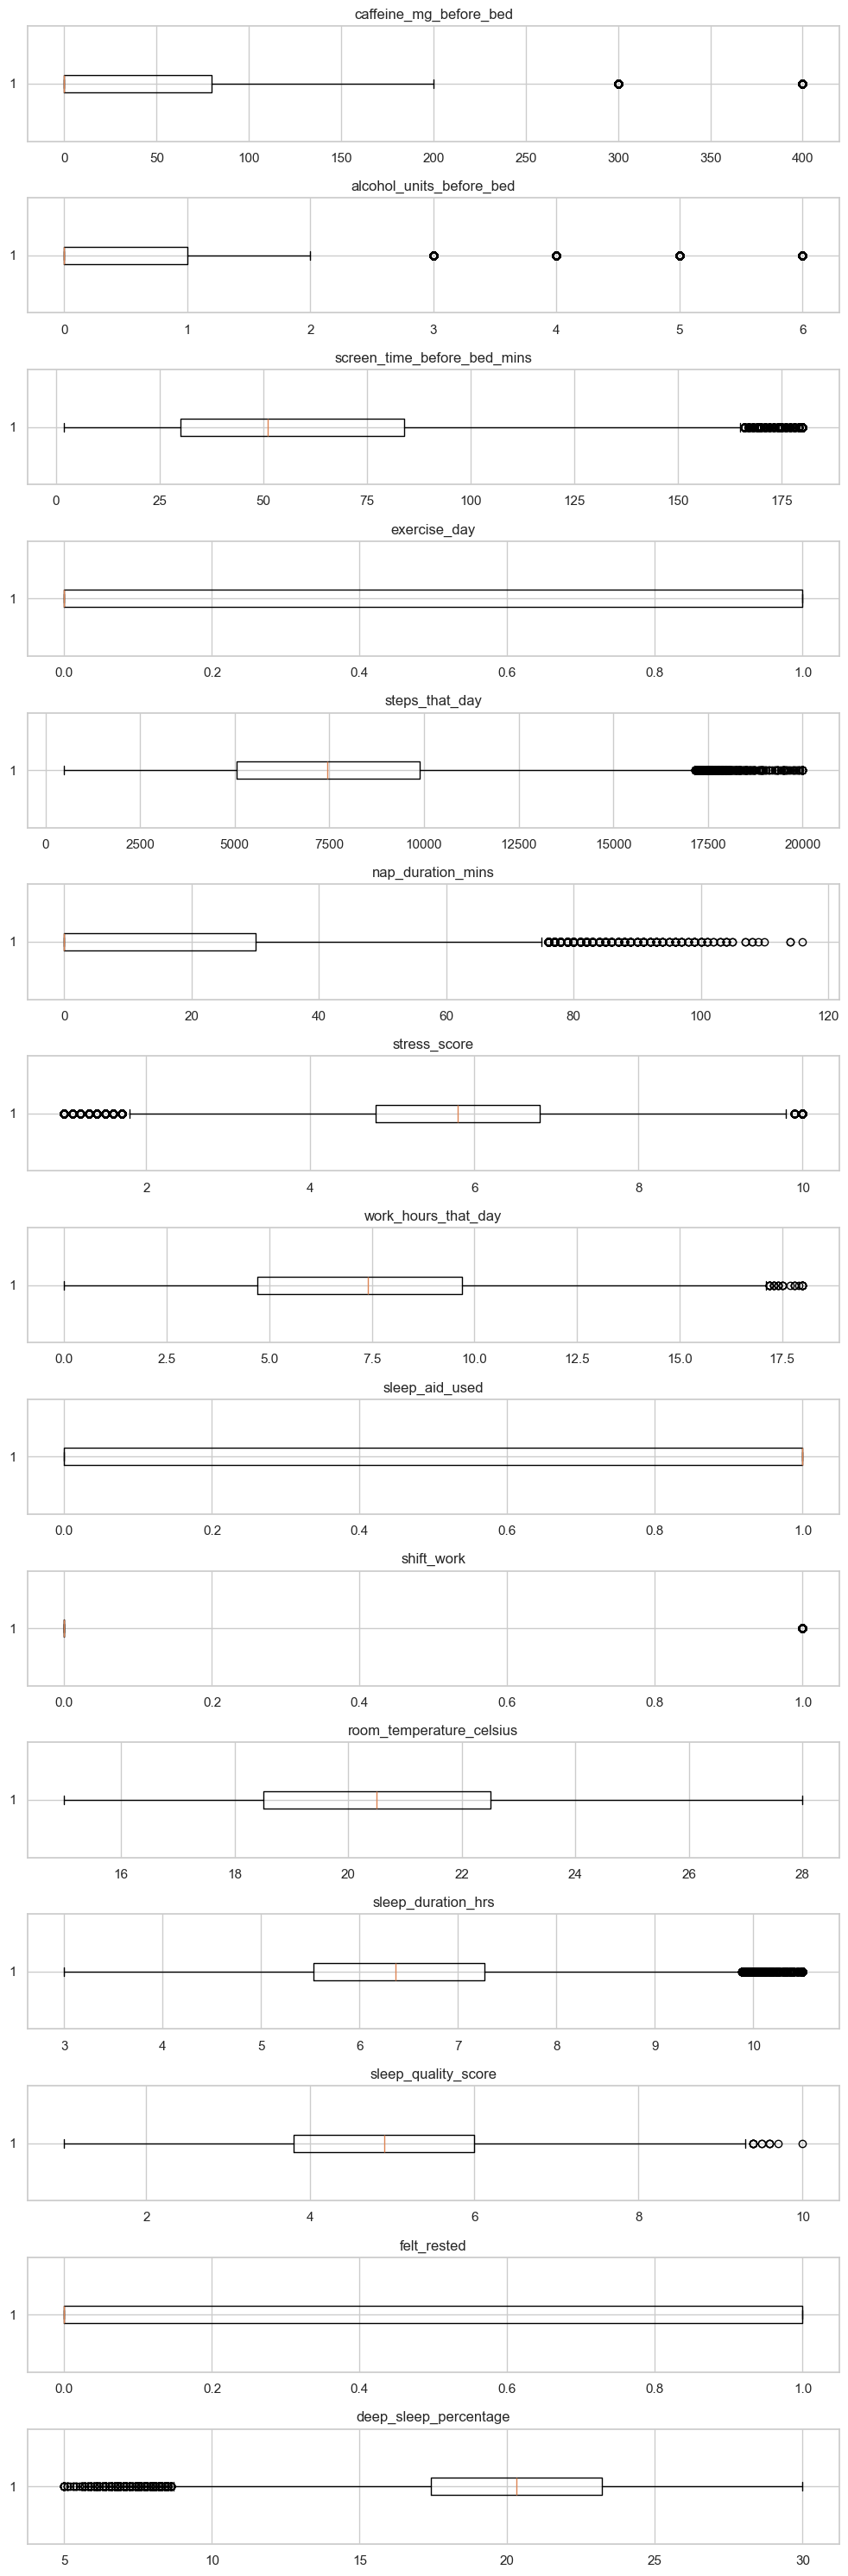

In [7]:
# Outlier detection using boxplots for numeric columns
numeric_columns = EFFECTING_FACTORS + OUTCOME_VARIABLES
fig, axes = plt.subplots(len(numeric_columns), 1, 
                         figsize = (10, len(numeric_columns)*2))

for i, col in enumerate(numeric_columns):
    if col in df.columns:
        axes[i].boxplot(df[col].dropna(), vert=False)
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [8]:
# Z score method to flag extreem outliers
z_score = np.abs(stats.zscore(df[numeric_columns].dropna()))
outlier_mask = (z_score > 3).any(axis=1) # flag rows where any column has z score > 3
print(f"rows with at least one extreme outlier (|Z| > 3 ): {outlier_mask.sum()}")


rows with at least one extreme outlier (|Z| > 3 ): 13920


Outcome variable distribution  

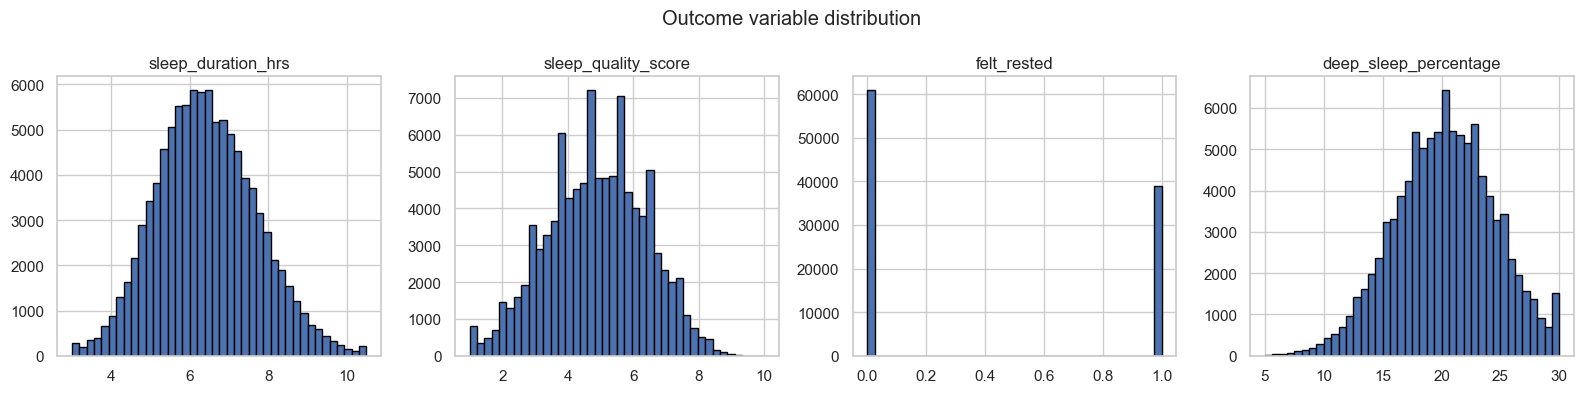

In [9]:
fig, axes = plt.subplots(1, len(OUTCOME_VARIABLES), figsize=(16,4))

# outputs each variable within each column as a bar in a histo
for i, col in enumerate(OUTCOME_VARIABLES):
    if col in df.columns:
        df[col].hist(bins=40, ax = axes[i], edgecolor='black')
        axes[i].set_title(col)


# modifies the title and layout to make it look better
plt.suptitle("Outcome variable distribution")
plt.tight_layout()
plt.show()

Correlation heatmap 

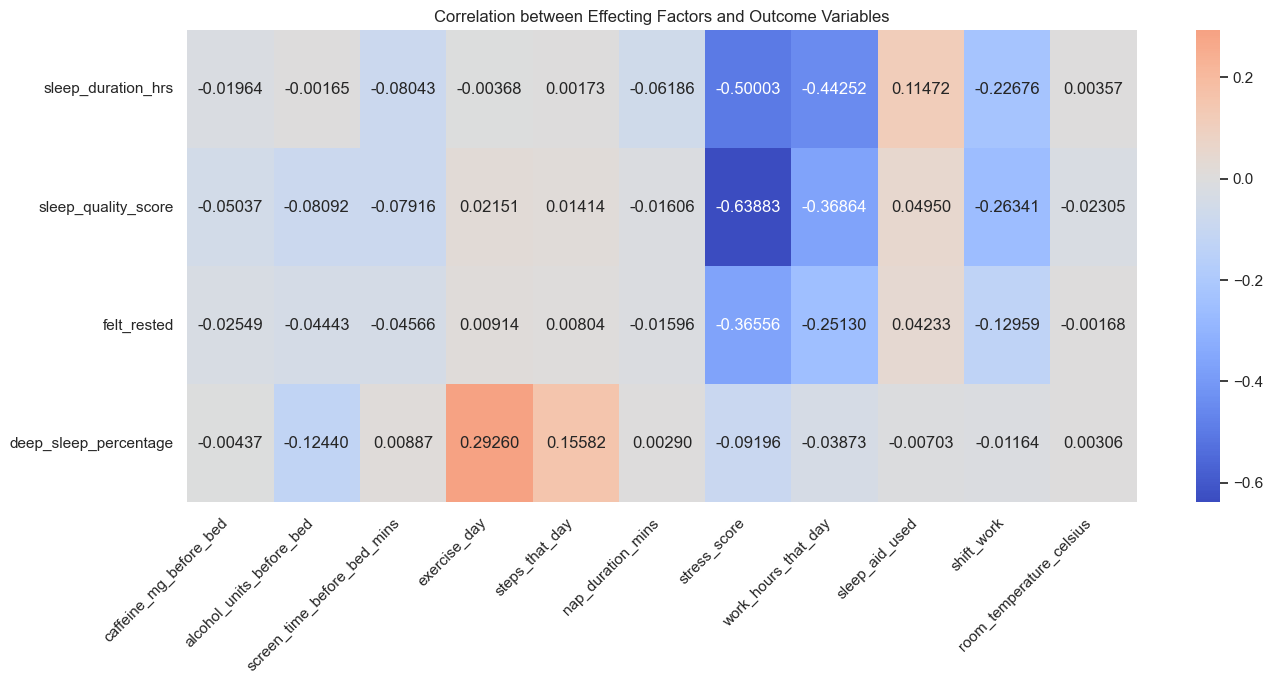

In [10]:
# sets columns to coorelate
columns_to_correlate = [c for c in EFFECTING_FACTORS + OUTCOME_VARIABLES 
                        if c in df.columns]

# computes correlation matrix for selected columns
correlation = df[columns_to_correlate].corr() 

# subsets the correlation matrix to only include rows of OUTCOME_VARIABLES and columns of EFFECTING_FACTORS
correlation_subset = correlation.loc[
    [c for c in OUTCOME_VARIABLES if c in df.columns],
    [c for c in EFFECTING_FACTORS if c in df.columns]
]

# grpahs
plt.figure(figsize=(14,7))
sns.heatmap(correlation_subset, 
            annot=True, 
            fmt=".5f", 
            cmap='coolwarm', 
            center=0)
plt.title("Correlation between Effecting Factors and Outcome Variables")

plt.xticks(rotation=45, ha='right')  # tilt for readability
plt.yticks(rotation=0)               # keep clean
plt.tight_layout()
plt.show()

Categorical vs outcome plots

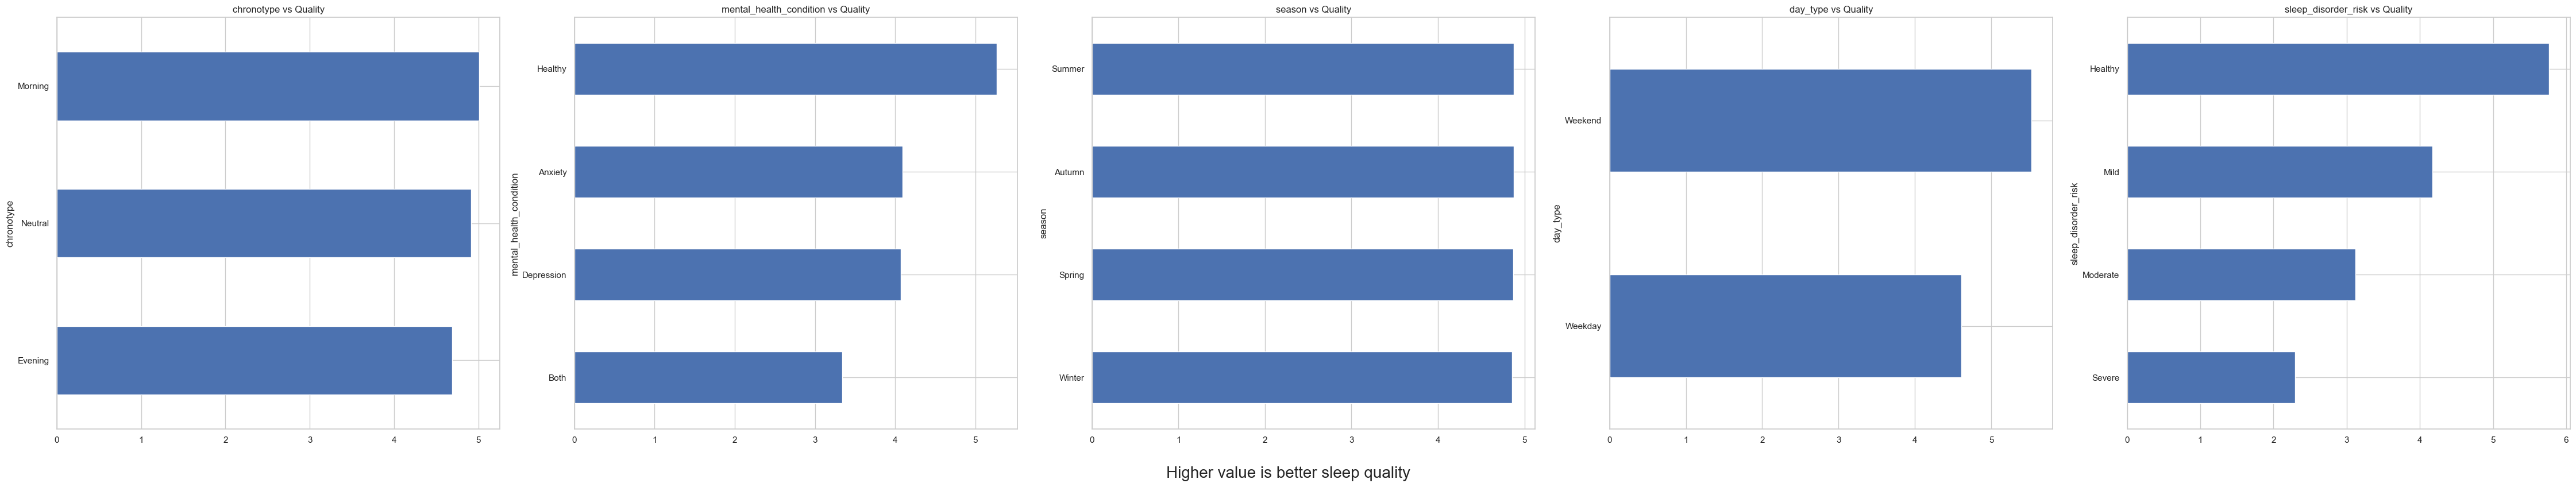

In [11]:
categorical_variables = ["chronotype", 
                        "mental_health_condition", 
                        "season", 
                        "day_type", 
                        "sleep_disorder_risk"]

target_variable = "sleep_quality_score"

fig, axes = plt.subplots(1, len(categorical_variables), figsize=(45,8))

for i, category in enumerate(categorical_variables):
    if category in df.columns and target_variable in df.columns:
        df.groupby(category)[target_variable].mean().sort_values().plot(kind='barh', ax=axes[i], title=f"{category} vs Quality")
        
fig.text(
    0.5,              # center horizontally
    -0.05,            # move below plots
    "Higher value is better sleep quality",  # caption text
    ha='center',
    fontsize=20
)

plt.tight_layout()
plt.show()

Feature engineering & model training

In [12]:
# Cell 1 - imports for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

import xgboost as xgb # model that can handle both regression and classification, known for its performance and efficiency
import joblib # saves trained model to disk for later use

Define features and targets

In [13]:
CONTINUOUS_OUTCOMES = ['sleep_duration_hrs', 
                       'sleep_quality_score', 
                       'deep_sleep_percentage']

BINARY_OUTCOME = ['felt_rested']

CATERGORICAL_COLUMNS = ['gender', 'occupation', 'country', 'chronotype', 
                        'mental_health_condition', 'season', 'day_type']

# Converting categories into numberd based order
ORDINAL_COLUMNS = ['sleep_disorder_risk']
ORDINAL_ORDERS = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe':3}


EXCLUDE_COLUMNS = ['person_id', 'felt_rested', 'rem_percentage', 
                'sleep_latency_mins', 'wake_episodes_per_night',
                'heart_rate_resting_bpm', 'cognitive_performance_score']


FEATURE_COLUMNS = EFFECTING_FACTORS + PREDETERMINED_FACTORS + DEMOGRAPHICS

Encode Categories

In [14]:
df_model = df.copy()

#ordinal encoding for sleep disorder risks
df_model['sleep_disorder_risk'] = df_model['sleep_disorder_risk'].map(ORDINAL_ORDERS)

# one hot encode remaining categories
df_model = pd.get_dummies(df_model, columns=CATERGORICAL_COLUMNS, drop_first=True)

# save the new columns names after encoding, (needed for dashboard)
feature_column_encoded = [col for col in df_model.columns
                          if col not in CONTINUOUS_OUTCOMES + EXCLUDE_COLUMNS]



print(f"total features after encoding: {len(feature_column_encoded)}")
print(feature_column_encoded)

total features after encoding: 51
['age', 'bmi', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'sleep_disorder_risk', 'gender_Male', 'gender_Other', 'occupation_Driver', 'occupation_Freelancer', 'occupation_Homemaker', 'occupation_Lawyer', 'occupation_Manager', 'occupation_Nurse', 'occupation_Retired', 'occupation_Sales', 'occupation_Software Engineer', 'occupation_Student', 'occupation_Teacher', 'country_Brazil', 'country_Canada', 'country_France', 'country_Germany', 'country_India', 'country_Italy', 'country_Japan', 'country_Mexico', 'country_Netherlands', 'country_South Korea', 'country_Spain', 'country_Sweden', 'country_UK', 'country_USA', 'chronotype_Morning', 'chronotype_Neutral', 'mental_health_condition_Both', 'mental_health_condition_Depression', 'mental_health_

Splitting training data and testing data

In [15]:
X = df_model[feature_column_encoded] # all features
y_continuous = df_model[CONTINUOUS_OUTCOMES] # the three continous ( duration, quality score, deep sleep percentage)
y_binary = df_model[BINARY_OUTCOME] # binary (felt rested or not)

X_train, X_test, yc_train, yc_test, yb_train, yb_test = train_test_split(
    X, y_continuous, y_binary, test_size=0.25, random_state=42
) #splits 75% data into training, 25% into evaualtion, random state ensures reproducibility

print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

Training rows: 75000, Test rows: 25000


Training the regression model for continuous outcomes and classifier

In [16]:
regressor = xgb.XGBRegressor(
    n_estimators=500, # number of trees, more = higher learning capacity but also risk over fitting
    learning_rate=0.05, # smaller learning rate means the model takes more time to learn (affect performance). higher is faster yet riskier
    max_depth=4, # control the depth of each estimator, higher value means it will seek for more complex patterns but also risk overfitting
    subsample=0.9,
    colsample_bytree=0.9,
    # controls the % features used per tree
    random_state=42, # seed for randomization
    n_jobs=-1 # uses all cpu cores for faster training
)

regressor.fit(X_train, yc_train)

# Evaluate regression model
yc_pred = regressor.predict(X_test)
yc_pred_df = pd.DataFrame(yc_pred, columns=CONTINUOUS_OUTCOMES)

print("Regression model performance:")
for col in CONTINUOUS_OUTCOMES:
    # Average prediction error
    mae = mean_absolute_error(yc_test[col].values, yc_pred_df[col].values)
    # how much variance model explains compared to a simple mean prediction
    r2 = r2_score(yc_test[col].values, yc_pred_df[col].values)
    print(f'{col}: MAE = {mae:.4f}, r2 = {r2:.4f}')


Regression model performance:
sleep_duration_hrs: MAE = 0.5761, r2 = 0.6577
sleep_quality_score: MAE = 0.6737, r2 = 0.6898
deep_sleep_percentage: MAE = 2.7624, r2 = 0.3310


In [17]:
classifier = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

classifier.fit(X_train, yb_train)


# Classifier
yb_pred = classifier.predict(X_test)
print("\nClassification model performance:")
print(f'Accuracy: {accuracy_score(yb_test, yb_pred):.4f}')
print(classification_report(yb_test, yb_pred))


Classification model performance:
Accuracy: 0.7192
              precision    recall  f1-score   support

           0       0.76      0.79      0.77     15224
           1       0.65      0.60      0.63      9776

    accuracy                           0.72     25000
   macro avg       0.70      0.70      0.70     25000
weighted avg       0.72      0.72      0.72     25000



Tuning model w/ cross validation OPTIONAL

In [ ]:
# Fine tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=10,
    cv=2,
    scoring='r2',
    random_state=42,
    verbose=1
)

search.fit(X_train, yc_train)
print("Best params:", search.best_params_)
print("Best R²:", search.best_score_)

best_regressor = xgb.XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
best_regressor.fit(X_train, yc_train)
yc_pred = best_regressor.predict(X_test)
# same MAE/R² code as before

'\n# Fine tuning with RandomizedSearchCV\nfrom sklearn.model_selection import RandomizedSearchCV\n\nparam_grid = {\n    \'n_estimators\': [300, 500],\n    \'max_depth\': [4, 6, 8],\n    \'learning_rate\': [0.01, 0.05, 0.1],\n    \'subsample\': [0.7, 0.8, 0.9],\n    \'colsample_bytree\': [0.7, 0.8, 0.9]\n}\n\nsearch = RandomizedSearchCV(\n    xgb.XGBRegressor(random_state=42, n_jobs=-1),\n    param_grid,\n    n_iter=10,\n    cv=2,\n    scoring=\'r2\',\n    random_state=42,\n    verbose=1\n)\n\nsearch.fit(X_train, yc_train)\nprint("Best params:", search.best_params_)\nprint("Best R²:", search.best_score_)\n\nbest_regressor = xgb.XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)\nbest_regressor.fit(X_train, yc_train)\nyc_pred = best_regressor.predict(X_test)\n# same MAE/R² code as before\n'

Feature Importance

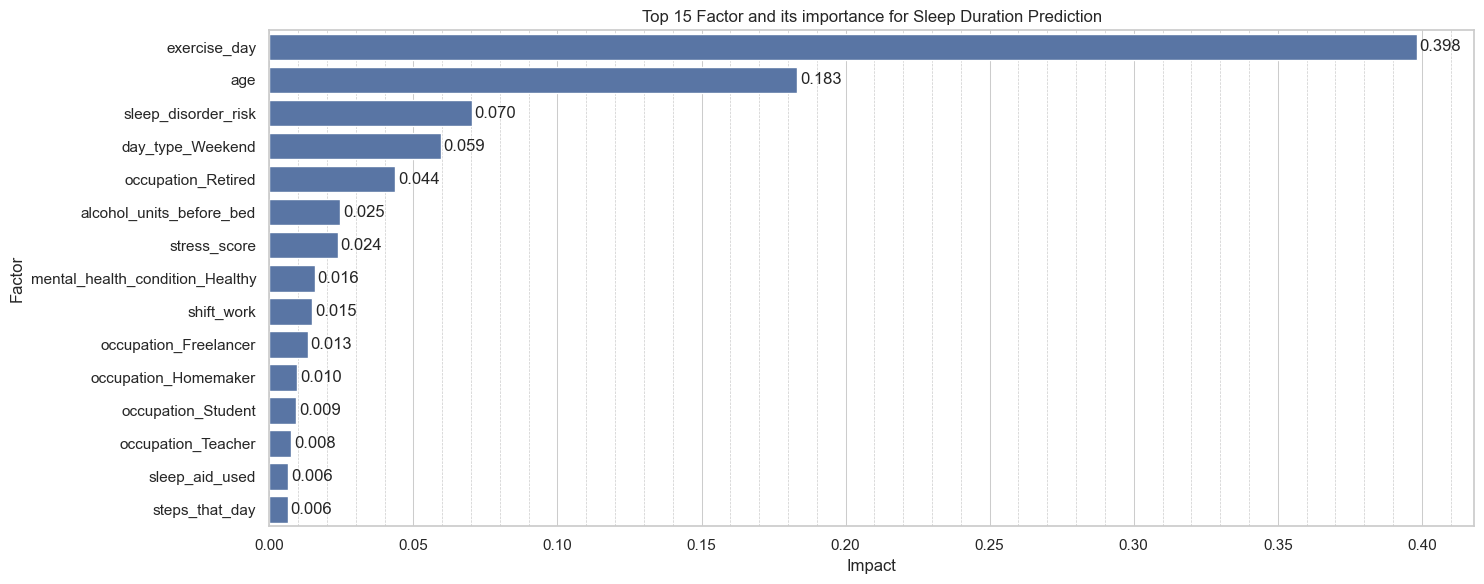

In [19]:
from matplotlib.ticker import MultipleLocator

importance_df = pd.DataFrame({
    'feature': feature_column_encoded,
    'importance': regressor.feature_importances_})\
        .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(15,6))

ax = sns.barplot(data=importance_df, x='importance', y='feature')

ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.grid(which='major', axis='x', linestyle='-', linewidth=0.75)
ax.grid(which='minor', axis='x', linestyle='--', linewidth=0.5)
        
for i, v in enumerate(importance_df['importance']):
    ax.text(v + 0.001, i, f"{v:.3f}", va='center')
plt.title("Top 15 Factor and its importance for Sleep Duration Prediction")
plt.xlabel("Impact")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()

In [20]:
joblib.dump(regressor, 'models/regressor.pkl')
joblib.dump(classifier, 'models/classifier.pkl')
joblib.dump(feature_column_encoded, 'models/feature_cols.pkl')
joblib.dump(ORDINAL_ORDERS, 'models/ordinal_order.pkl')

print("Models and metadata saved.")

Models and metadata saved.
